# Capítulo 3 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 3. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

Cp, Rd, g, Lv = 1004.0, 287.0, 9.8, 2.5e6
Gamma_d = g/Cp

## T1 — $\Gamma_d$ na Terra e em Marte

**Solução.** Adiabático: $c_p\,dT = \alpha\,dP$; hidrostática: $dP = -\rho g\,dz$, e $\alpha\rho = 1$:
$$c_p\,dT = -g\,dz \;\Rightarrow\; \frac{dT}{dz} = -\frac{g}{c_p}.$$
Nem $T$ nem $P$ aparecem: o gradiente é constante (enquanto $g$ e $c_p$ forem). Em Marte, atmosfera de CO₂:

In [2]:
print(f'Terra: Γd = {9.8/1004*1e3:.2f} K/km')
print(f'Marte: Γd = {3.7/845*1e3:.2f} K/km — menor g e cp parecido: parcela esfria menos ao subir.')

Terra: Γd = 9.76 K/km
Marte: Γd = 4.38 K/km — menor g e cp parecido: parcela esfria menos ao subir.


## T2 — Dedução de $\theta$ e sua aproximação linear

**Solução.** De $c_p\,dT/T = \Re_d\,dP/P$, integrando de $(T, P)$ a $(\theta, P_0)$:
$$c_p\ln\frac{\theta}{T} = \Re_d\ln\frac{P_0}{P}\;\Rightarrow\;\theta = T\left(\frac{P_0}{P}\right)^{\Re_d/c_p}.$$
Para a aproximação: com $P \approx P_0 e^{-z/H}$ e expandindo em $z/H$ pequeno, $\theta \approx T\,(1 + \Re_d z/(c_p H))$; como $H = \Re_d \bar T/g$, o termo extra é $T\,g z/(c_p \bar T) \approx \Gamma_d z$. ∎

In [3]:
# verificação simbólica da integração
T_, P_, P0_, cp_, Rd_ = sp.symbols('T P P_0 c_p R_d', positive=True)
theta_ = sp.Function('theta', positive=True)
# dθ/θ ao longo da adiabática = 0 ⇔ d(T P^{-Rd/cp}) = 0; verificamos por diferencial
expr = T_*(P0_/P_)**(Rd_/cp_)
dtheta = sp.simplify(sp.diff(expr, T_)*sp.Symbol('dT') + sp.diff(expr, P_)*sp.Symbol('dP'))
# na adiabática, dT = (Rd T)/(cp P) dP:
dtheta_adiab = sp.simplify(dtheta.subs(sp.Symbol('dT'), Rd_*T_/(cp_*P_)*sp.Symbol('dP')))
print('dθ ao longo da adiabática =', dtheta_adiab, ' → θ conservada ✓')

dθ ao longo da adiabática = 0  → θ conservada ✓


## T3 — $\theta$ é a entropia disfarçada

**Solução.** Da 2ª lei para processo reversível, $ds = \delta q/T$; com a 1ª lei:
$$ds = c_p\frac{dT}{T} - \frac{\alpha}{T}dP = c_p\frac{dT}{T} - \Re_d\frac{dP}{P}.$$
Por outro lado, $\ln\theta = \ln T + (\Re_d/c_p)(\ln P_0 - \ln P)$, logo
$$c_p\,d\ln\theta = c_p\frac{dT}{T} - \Re_d\frac{dP}{P} = ds.\;∎$$
Adiabático reversível ⇒ $ds = 0$ ⇒ $\theta$ constante: superfícies isentrópicas = superfícies de $\theta$.

## T4 — Solução geral da advecção pura

In [4]:
# verificação simbólica: T(x,t) = f(x - U t) satisfaz ∂T/∂t + U ∂T/∂x = 0
x_, t_, U_ = sp.symbols('x t U')
f = sp.Function('f')
T_sol = f(x_ - U_*t_)
residuo = sp.simplify(sp.diff(T_sol, t_) + U_*sp.diff(T_sol, x_))
print('∂T/∂t + U ∂T/∂x =', residuo, ' — qualquer forma f viaja rígida ✓')

∂T/∂t + U ∂T/∂x = 0  — qualquer forma f viaja rígida ✓


## T5 — Partição de Bowen e evaporação

**Solução.** Com $F^* - F_G = F_H + F_E$ e $\beta = F_H/F_E$:
$$F_E = \frac{F^* - F_G}{1+\beta},\qquad F_H = \frac{\beta\,(F^* - F_G)}{1+\beta}.$$

In [5]:
disp = 500.0 - 50.0     # F* - FG
for nome, beta in [('deserto', 5.0), ('floresta', 0.2)]:
    FE = disp/(1+beta); FH = disp - FE
    evap = FE/Lv*3600    # kg m-2 h-1 = mm/h
    print(f'{nome:9s}: FH = {FH:5.0f} W/m² | FE = {FE:5.0f} W/m² | '
          f'evaporação = {evap:.2f} mm/h')
print('\nA floresta evapora ~0,5 mm/h — um "chuveiro invertido" que climatiza a tarde.')

deserto  : FH =   375 W/m² | FE =    75 W/m² | evaporação = 0.11 mm/h
floresta : FH =    75 W/m² | FE =   375 W/m² | evaporação = 0.54 mm/h

A floresta evapora ~0,5 mm/h — um "chuveiro invertido" que climatiza a tarde.


---
## N1 — Parcela adiabática: exata × aproximada

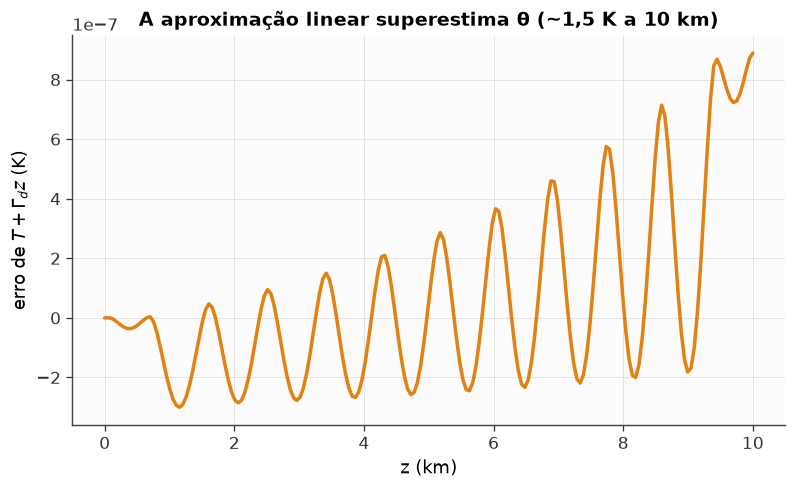

θ conservada com desvio de 0.00 mK; erro da aproximação a 10 km: 0.00 K


In [6]:
T0, P0 = 303.15, 100.0
def parcela(z, y):
    T, P = y
    return [-g/Cp, -(P*1e3/(Rd*T))*g/1e3]
z = np.linspace(0, 10e3, 200)
sol = solve_ivp(parcela, [0, 10e3], [T0, P0], t_eval=z, rtol=1e-10)
T_p, P_p = sol.y
theta_ex = T_p*(P0/P_p)**(Rd/Cp)
theta_ap = T_p + Gamma_d*z

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(z/1e3, theta_ap - theta_ex, color=CORES['laranja'])
ax.set(xlabel='z (km)', ylabel='erro de $T+\\Gamma_d z$ (K)',
       title='A aproximação linear superestima θ (~1,5 K a 10 km)')
plt.show()
print(f'θ conservada com desvio de {abs(theta_ex[-1]-theta_ex[0])*1e3:.2f} mK; '
      f'erro da aproximação a 10 km: {theta_ap[-1]-theta_ex[-1]:.2f} K')

## N2 — Continental × oceânico: amplitude e defasagem

In [7]:
sigma_SB, eps, T_ar, T_ceu, h_turb, S_max = 5.67e-8, 0.95, 298.0, 270.0, 15.0, 900.0
S_solar = lambda th: np.maximum(0.0, S_max*np.sin(np.pi*((th % 24) - 6)/12))
def balanço(th, Ts, C, A, beta):
    FH = h_turb*(Ts[0] - T_ar); FE = FH/beta
    return [((1-A)*S_solar(th) - eps*sigma_SB*(Ts[0]**4 - T_ceu**4) - FH - FE)/C*3600]

t = np.linspace(48, 72, 600)   # 3º dia (já em regime)
for nome, C in [('continental', 1.0e5), ('oceânica', 4.0e6)]:
    sol = solve_ivp(balanço, [0, 72], [T_ar], args=(C, 0.2, 0.5),
                    t_eval=t, max_step=0.1)
    Ts = sol.y[0]
    amp = Ts.max() - Ts.min()
    h_max = t[np.argmax(Ts)] % 24
    print(f'{nome:12s}: amplitude = {amp:5.1f} K | máximo às {h_max:4.1f} h '
          f'(meio-dia solar = 12 h)')
print('\nLaje pesada: amplitude despenca e o máximo atrasa — é a inércia térmica dos oceanos.')

continental : amplitude =  14.0 K | máximo às 12.5 h (meio-dia solar = 12 h)
oceânica    : amplitude =   2.7 K | máximo às 16.4 h (meio-dia solar = 12 h)

Laje pesada: amplitude despenca e o máximo atrasa — é a inércia térmica dos oceanos.


## N3 — Difusão numérica × resolução

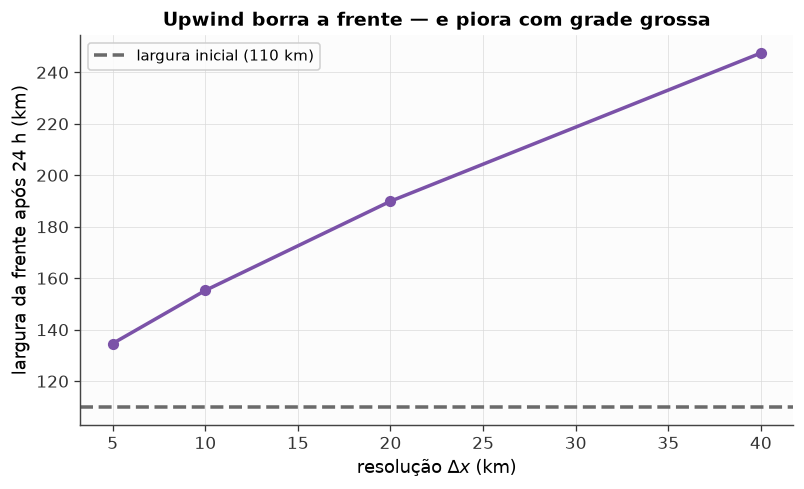

Δx =    5 km → largura =   135 km
Δx =   10 km → largura =   155 km
Δx =   20 km → largura =   190 km
Δx =   40 km → largura =   247 km


In [8]:
L, U = 2000e3, 10.0
frente = lambda x, c: 25.0 - 5.0*(1 + np.tanh((x - c)/50e3))

def largura_frente(dx):
    x = np.arange(0, L, dx)
    T = frente(x, 400e3)
    dt = 0.8*dx/U
    ts = 0.0
    while ts < 24*3600:
        T[1:] = T[1:] - U*dt/dx*(T[1:] - T[:-1]); ts += dt
    x24 = np.interp(-24.0, -T, x)    # T decresce com x → inverter p/ interp
    x16 = np.interp(-16.0, -T, x)
    return (x16 - x24)/1e3

dxs = np.array([5e3, 10e3, 20e3, 40e3])
largs = [largura_frente(d) for d in dxs]

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(dxs/1e3, largs, 'o-', color=CORES['roxo'])
larg0 = (np.interp(-16.0, -frente(np.arange(0, L, 1e3), 400e3),
                   np.arange(0, L, 1e3))
         - np.interp(-24.0, -frente(np.arange(0, L, 1e3), 400e3),
                     np.arange(0, L, 1e3)))/1e3
ax.axhline(larg0, color=CORES['cinza'], ls='--',
           label=f'largura inicial ({larg0:.0f} km)')
ax.set(xlabel='resolução $\\Delta x$ (km)', ylabel='largura da frente após 24 h (km)',
       title='Upwind borra a frente — e piora com grade grossa')
ax.legend()
plt.show()
for d, l in zip(dxs, largs):
    print(f'Δx = {d/1e3:4.0f} km → largura = {l:5.0f} km')

## N4 — Topo da camada de mistura por $\theta_v$

In [9]:
from metpy.units import units
import metpy.calc as mpcalc

P_s  = np.array([1000, 925, 850, 700, 500]) * units.hPa
z_s  = np.array([80, 760, 1480, 3120, 5830]) * units.m
T_s  = np.array([27.0, 22.0, 17.5, 9.0, -6.5]) * units.degC
Td_s = np.array([22.0, 19.0, 15.0, 5.0, -14.0]) * units.degC

r_s = mpcalc.mixing_ratio_from_relative_humidity(
         P_s, T_s, mpcalc.relative_humidity_from_dewpoint(T_s, Td_s))
thv = mpcalc.virtual_potential_temperature(P_s, T_s, r_s).to('K')

excesso = thv - thv[0]
print('nível    θv (K)   θv - θv(sfc)')
for P, z, tv, ex in zip(P_s, z_s, thv, excesso):
    marca = '  ← topo da camada de mistura' if ex.magnitude > 0.5 else ''
    print(f'{P.magnitude:5.0f} hPa {tv.magnitude:7.1f} {ex.magnitude:+8.1f}{marca}')
    if ex.magnitude > 0.5:
        break
print('\nCritério de 0,5 K: o topo fica entre a superfície e o primeiro nível marcado;')
print('com sondagem de alta resolução o método fixa z_i com ~50 m de precisão (Cap. 18).')

nível    θv (K)   θv - θv(sfc)
 1000 hPa   303.2     +0.0
  925 hPa   304.5     +1.4  ← topo da camada de mistura

Critério de 0,5 K: o topo fica entre a superfície e o primeiro nível marcado;
com sondagem de alta resolução o método fixa z_i com ~50 m de precisão (Cap. 18).


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*